# CNN - Convolutional Neural Network (TensorFlow / Keras)

A CNN replaces some fully-connected layers with **convolutional** layers that slide
small learned filters across an image, exploiting the fact that nearby pixels are
related. This needs far fewer parameters than a plain [`ANN`](../02_ANN) for image
data and tends to generalize better.

We classify the same handwritten digits as in `02_ANN`, but this time keep them as
real 8x8 **images** (`sklearn.datasets.load_digits`) instead of flattening them, and
feed them through a small Conv -> Pool -> Conv -> Pool -> Dense network.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

tf.random.set_seed(0)

In [2]:
digits = load_digits()
X = digits.images / 16.0  # (1797, 8, 8) pixel intensities, scaled to [0, 1]
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# add a channel dimension: (N, 8, 8, 1) — Keras conv layers expect channels-last
X_train = X_train[..., None]
X_test = X_test[..., None]
X_train.shape

(1437, 8, 8, 1)

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(8, 8, 1)),
    tf.keras.layers.Conv2D(8, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 8)        │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,898 (7.41 KB)

 Trainable params: 1,898 (7.41 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(X_train, y_train, epochs=30, verbose=0)
print("final training loss:", history.history["loss"][-1])

final training loss: 0.01317403744906187


Test accuracy: 0.978


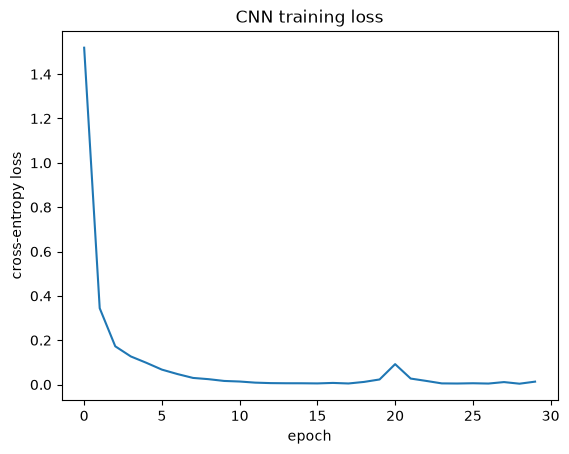

In [5]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")

plt.plot(history.history["loss"])
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("CNN training loss")
plt.show()